In [1]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime
import numpy as np

from chirpy.geometry import ImageGrid2D, TransducerArray2D, GeometryConfigurator
from chirpy.data.image_data import ImageData

from chirpy.optimization.operator import WaveOperator
from chirpy.utils.progress import Progress, ProgressConfig
from chirpy.signals import GaussianModulatedPulse
from chirpy.utils.dtft_wavefield import dtft_wavefield

from scipy.io import savemat

In [2]:
DAT_PATH = Path("../../data/NumerialBreastPhantoms/Neg_07_Left/MergedPhantom.DAT")

In [3]:
# DAT_PATH = Path("data/NumerialBreastPhantoms/Neg_07_Left/MergedPhantom.DAT")
#
# ROOT_DIR = Path.cwd()
# DATA_PATH = Path(ROOT_DIR / DAT_PATH)

# -------------------- Configuration --------------------
SAVE_DIR = Path("outputs/neural_operator_data_wave_gen")
SAVE_DIR.mkdir(exist_ok=True, parents=True)

use_gpu = False

# Phantom source
KWAVE_DIR = None
NX, NY, NZ = 616, 485, 719  # raw 3D (x,y,z) used to extract a single x-slice
SLICE_AXIS_X_INDEX = NX // 2  # take the middle X-plane

# Acoustic mapping
SOUND_SPEED_MAP = {
    0: 1500.0,  # background / water
    2: 1540.0,  # fibroglandular
    3: 1450.0,  # fat
    4: 1555.0,  # skin
    5: 1548.0,  # vessel
}
DENSITY_MAP = {0: 1000.0, 2: 1040.0, 3: 911.0, 4: 1100.0, 5: 945.0}

# Grids
nx_grid = ny_grid = 240
dx_grid = dy_grid = 1e-3  # 1 mm spacing
xmax = 120e-3  # 240*240 mm field with nx=480/dx=0.5mm(fine) or nx=240/dx=1mm(coarse)

# Array & physics
N_TX = 512
RADIUS_M = 110e-3
F0 = 1e6
C0_BG = 1500.0

# Time record policy
RECORD_PAD = 1.3

# Frequencies
freqs = np.arange(0.3, 1.35, 0.05) * 1e6

# Progress
progress = Progress(ProgressConfig(enabled=True, backend="tqdm", ncols=90))

# Neural operator packaging
PACK_TENSORS = True

# Filenames
INC_DIR = SAVE_DIR / "incident_fields"
SCAT_DIR = SAVE_DIR / "scattered_fields"
INC_DIR.mkdir(exist_ok=True, parents=True)
SCAT_DIR.mkdir(exist_ok=True, parents=True)
NEURAL_DIR = SAVE_DIR / "neural_operator_data"
NEURAL_DIR.mkdir(exist_ok=True, parents=True)
NEURAL_NPZ = NEURAL_DIR / "neural_operator_training_data.npz"


# -------------------- Utilities --------------------
def log(msg: str) -> None:
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}")


def load_labels_slice(
        dat_path: Path, shape_xyz: tuple[int, int, int], x_index: int
) -> np.ndarray:
    """Load 3D uint8 labels in Fortran order and return one x-slice as (Ny, Nz)."""
    NX_, NY_, NZ_ = shape_xyz
    with open(dat_path, "rb") as f:
        raw = np.fromfile(f, dtype=np.uint8)
    raw = raw.reshape((NX_, NY_, NZ_), order="F")
    return raw[x_index, :, :]  # (Ny, Nz)


def labels_to_maps(labels_2d: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Map integer labels → sound speed & density arrays."""
    ss = np.zeros_like(labels_2d, dtype=np.float32)
    rho = np.zeros_like(labels_2d, dtype=np.float32)
    for lab, c in SOUND_SPEED_MAP.items():
        mask = labels_2d == lab
        ss[mask] = float(c)
        rho[mask] = float(DENSITY_MAP.get(lab, 1000.0))
    ss[ss <= 0] = SOUND_SPEED_MAP[3]  # default unmapped to fat
    return ss, rho


def pad_to_square(arr: np.ndarray, target: int, bg: float = 1500.0) -> np.ndarray:
    """
    Center-pad a 2D array to (target, target) using constant background value.
    """
    ny, nx = arr.shape
    if target < max(ny, nx):
        raise ValueError(f"target={target} < original size {(ny, nx)}")

    # compute padding sizes
    pad_y = target - ny
    pad_x = target - nx

    pad_top = pad_y // 2
    pad_bottom = pad_y - pad_top
    pad_left = pad_x // 2
    pad_right = pad_x - pad_left

    arr_pad = np.pad(
        arr,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=float(bg),
    )
    return arr_pad


def compute_record_time(
        grid: ImageGrid2D, c_min: float, pad: float = RECORD_PAD
) -> float:
    extent = grid.extent
    width = extent[1] - extent[0]
    return float(pad * width / c_min)

[19:30:46] Loading phantom DAT and building sound-speed slice...


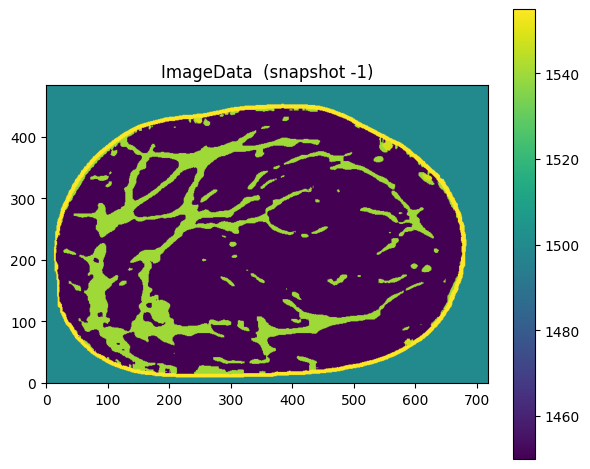

<Axes: title={'center': 'ImageData  (snapshot -1)'}>

In [4]:
log("Loading phantom DAT and building sound-speed slice...")
labels = load_labels_slice(DAT_PATH, (NX, NY, NZ), SLICE_AXIS_X_INDEX)  # (Ny, Nz)
c_raw, _rho_raw = labels_to_maps(labels)  # (Ny, Nz)
ImageData(c_raw).show(cmap="viridis")

[19:30:47] Padding to square 1024x1024


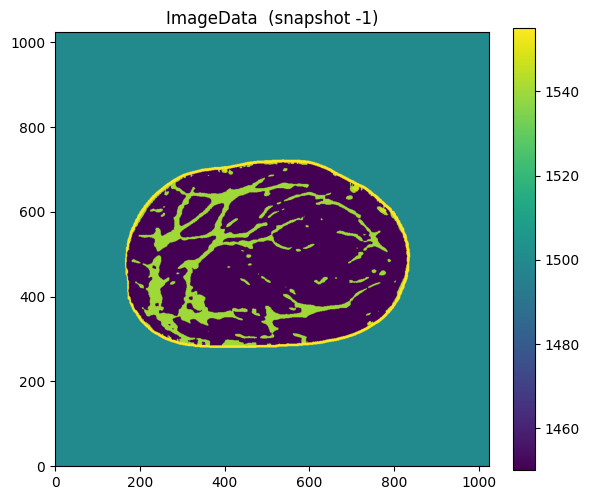

<Axes: title={'center': 'ImageData  (snapshot -1)'}>

In [5]:
log("Padding to square 1024x1024")
c_pad = pad_to_square(c_raw, target=1024, bg=1500.0)
ImageData(c_pad).show(cmap="viridis")

[19:30:47] Building target grid and downsampling true sound-speed map


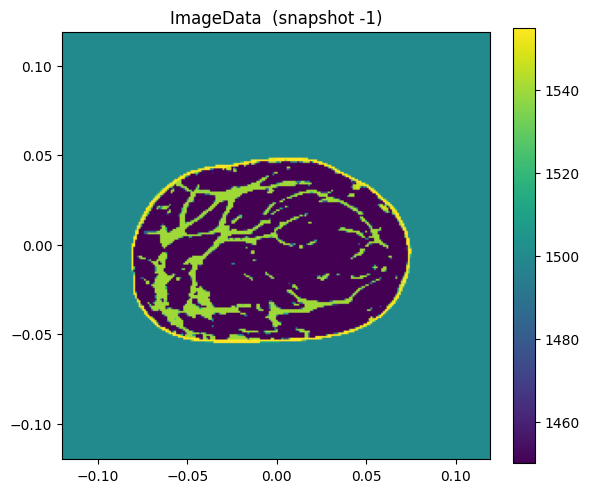

<Axes: title={'center': 'ImageData  (snapshot -1)'}>

In [6]:
log("Building target grid and downsampling true sound-speed map")
grid = ImageGrid2D(nx=nx_grid, dx=dx_grid)
c_true = ImageData(c_pad).downsample_to(new_grid=grid)
c_true.show(cmap="viridis")

[19:30:48] Building 512-elt ring and computing record time...


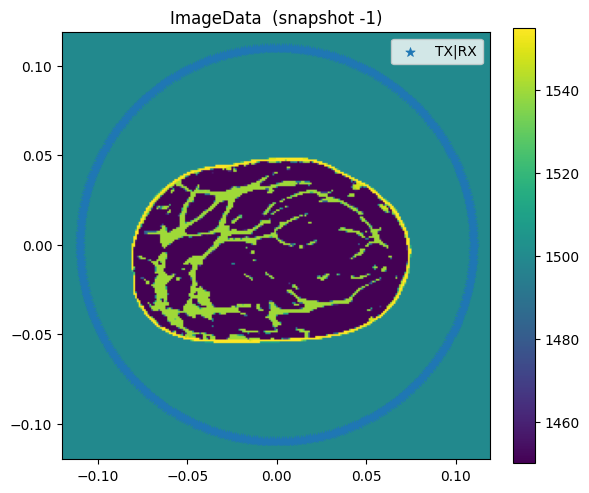

Reference sound speed: 1555.0 m/s
Minimum sound speed: 1450.0 m/s
Record time: 214.3 us


In [7]:
log("Building 512-elt ring and computing record time...")
tx_array = TransducerArray2D.from_ring_array_2D(r=RADIUS_M, grid=grid, n=N_TX)
geom_view = ImageData(array=c_true.array, grid=grid,tx_array=tx_array)
geom_view.show(cmap="viridis")

c_ref = float(np.max(c_true.array))
c_min = float(np.min(c_true.array))
record_time = compute_record_time(grid, c_min)
print(f"Reference sound speed: {c_ref} m/s")
print(f"Minimum sound speed: {c_min} m/s")
print(f"Record time: {record_time*1e6:.1f} us")

In [13]:
# downsample transmitters
geom_config = GeometryConfigurator(grid, tx_array)
geom_config.configure_acceptance(delta=0)
geom_config.select_tx(step=512)

print("Freqs: ", freqs)

Freqs:  [ 300000.  350000.  400000.  450000.  500000.  550000.  600000.  650000.
  700000.  750000.  800000.  850000.  900000.  950000. 1000000. 1050000.
 1100000. 1150000. 1200000. 1250000. 1300000.]


In [14]:
medium = {
    "density": np.full_like(c_true, 1000.0, dtype=np.float32),
    "alpha_coeff": np.zeros_like(c_true, dtype=np.float32),
    "alpha_power": 1.01,
    "alpha_mode": "no_dispersion",
}
pulse = GaussianModulatedPulse(f0=F0, frac_bw=0.75, amp=1.0)
op = WaveOperator(
    geom_config=geom_config,
    medium_params=medium,
    record_time=record_time,
    record_full_wf=True,
    pulse=pulse,
    c_ref=c_ref,
    use_gpu=use_gpu,
    binary_path=KWAVE_DIR,
    progress=progress,
    verbose=True,
)

[WaveOperator] Init → Tx=1, Rx=512, nt=1111, dt=1.929e-07s, grid=(240×240,1.00e-03×1.00e-03m), c_ref=1555.0m/s, cfl=0.3, pml=10, enc=False, tau_max=0.000e+00s, dsrx=False, full_wf=True, src_mode=additive, rx_order=element, pulse={'Type': 'GaussianModulatedPulse', 'attrs': {'f0': 1000000.0, 'frac_bw': 0.75, 'amp': 1.0, 'bwr': -6.0, 'tpr': -80.0}}


In [37]:
record_time

0.0002142758620689655

In [15]:
# ---- Incident fields (homogeneous c0) ----
c_hom = np.full_like(c_true.array, C0_BG, dtype=np.float32)
_ = op.forward(model=c_hom, kind='c')

┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      8 │
│ Processor name:                                  Apple M1 Pro │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                  280 x 280 │
│ Medium type:                                               2D │
│ Simulation time steps:                                   1111 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [16]:
incident_fields_td = op.get_forward_fields() # (Ntx, Nt, Ny, Nx)

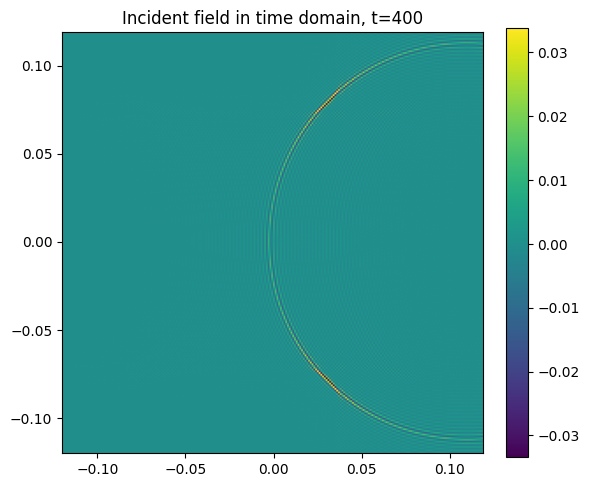

<Axes: title={'center': 'Incident field in time domain, t=400'}>

In [32]:
wv_view = incident_fields_td[0,400,:,:]
ImageData(array=wv_view, grid=grid).show(cmap="viridis", title="Incident field in time domain, t=400")

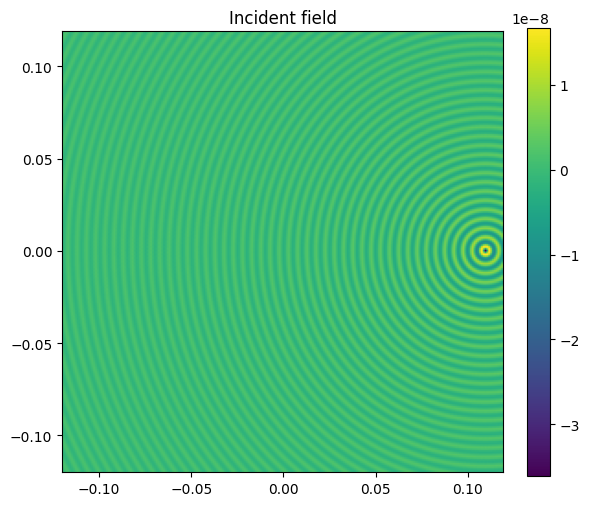

<Axes: title={'center': 'Incident field'}>

In [20]:
incident_fields_fd = dtft_wavefield(
    incident_fields_td,
    dt=op.dt,
    freqs=freqs,
)
# view tx0 at f_idx=0
ImageData(incident_fields_fd[:,:,0,0], grid=grid).show(cmap="viridis", title="Incident field")

In [24]:
# ---- Total fields in heterogeneous medium → scattered = total - incident ----
c_het = c_true.array
_ = op.forward(model=c_het, kind='c')
total_fields_td = op.get_forward_fields()  # (Ntx, Nt, Ny, Nx)

[WaveOperator] Init → Tx=1, Rx=512, nt=1111, dt=1.929e-07s, grid=(240×240,1.00e-03×1.00e-03m), c_ref=1555.0m/s, cfl=0.3, pml=10, enc=False, tau_max=0.000e+00s, dsrx=False, full_wf=True, src_mode=additive, rx_order=element, pulse={'Type': 'GaussianModulatedPulse', 'attrs': {'f0': 1000000.0, 'frac_bw': 0.75, 'amp': 1.0, 'bwr': -6.0, 'tpr': -80.0}}
┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      8 │
│ Processor name:                                  Apple M1 Pro │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                  280 

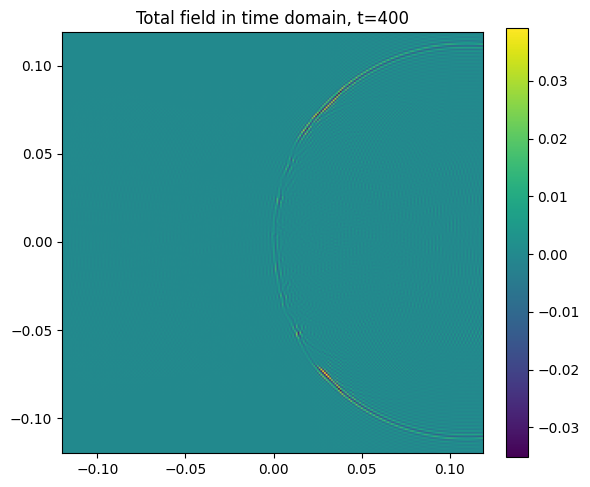

<Axes: title={'center': 'Total field in time domain, t=400'}>

In [33]:
wv_view = total_fields_td[0,400,:,:]
ImageData(array=wv_view, grid=grid).show(cmap="viridis", title="Total field in time domain, t=400")

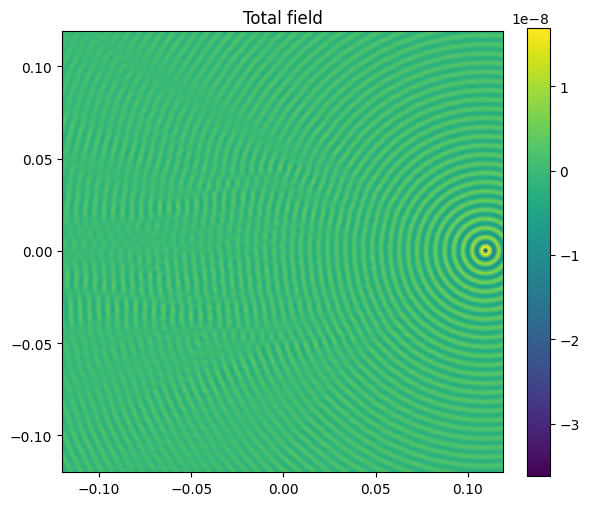

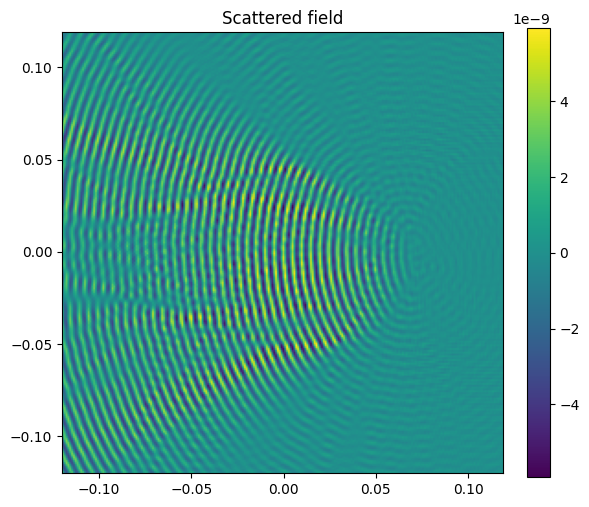

<Axes: title={'center': 'Scattered field'}>

In [31]:
total_fields_fd = dtft_wavefield(
    total_fields_td,
    dt=op.dt,
    freqs=freqs,
)
scattered_fields_fd = total_fields_fd - incident_fields_fd
# view tx0 at f_idx=0
ImageData(total_fields_fd[:,:,0,0], grid=grid).show(cmap="viridis", title="Total field")
ImageData(scattered_fields_fd[:,:,0,0], grid=grid).show(cmap="viridis", title="Scattered field")